# Regression

In this notebook, we will look at some different regression techniques using the Hitters dataset - we attempt to predict the salary of a baseball player from their performance on the field!

In [1]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
#importing, dropping NaNs, removing name variables, one-hot-encoding, etc.
df = pd.read_csv('Hitters.csv')
df = pd.read_csv('Hitters.csv').dropna().drop(df.columns[0], axis = 1)
dummies = pd.get_dummies(df[['League', 'Division', 'NewLeague']])
y = df.Salary
X_ = df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis = 1).astype('float64')
X = pd.concat([X_, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis = 1)
X.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
1,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,321.0,414.0,375.0,632.0,43.0,10.0,True,True,True
2,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,224.0,266.0,263.0,880.0,82.0,14.0,False,True,False
3,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,225.0,828.0,838.0,354.0,200.0,11.0,3.0,True,False,True
4,321.0,87.0,10.0,39.0,42.0,30.0,2.0,396.0,101.0,12.0,48.0,46.0,33.0,805.0,40.0,4.0,True,False,True
5,594.0,169.0,4.0,74.0,51.0,35.0,11.0,4408.0,1133.0,19.0,501.0,336.0,194.0,282.0,421.0,25.0,False,True,False


In [3]:
scaler = StandardScaler().fit(X) #scaling the data, otherwise Ridge and Lasso won't work
X_scaled = scaler.transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=1)

## Ordinary least squares regression (OLS)

In [4]:
ols = LinearRegression()
ols.fit(X_train, y_train)

print("r^2 on train data is {}".format(ols.score(X_train, y_train)))
print("r^2 on test data is {}".format(ols.score(X_test, y_test)))

r^2 on train data is 0.566544619704869
r^2 on test data is 0.4003457419200571


The model is not fantastic and also there's some overfitting going on.

Intercept: 525.7213868883011


Text(0, 0.5, 'Feature')

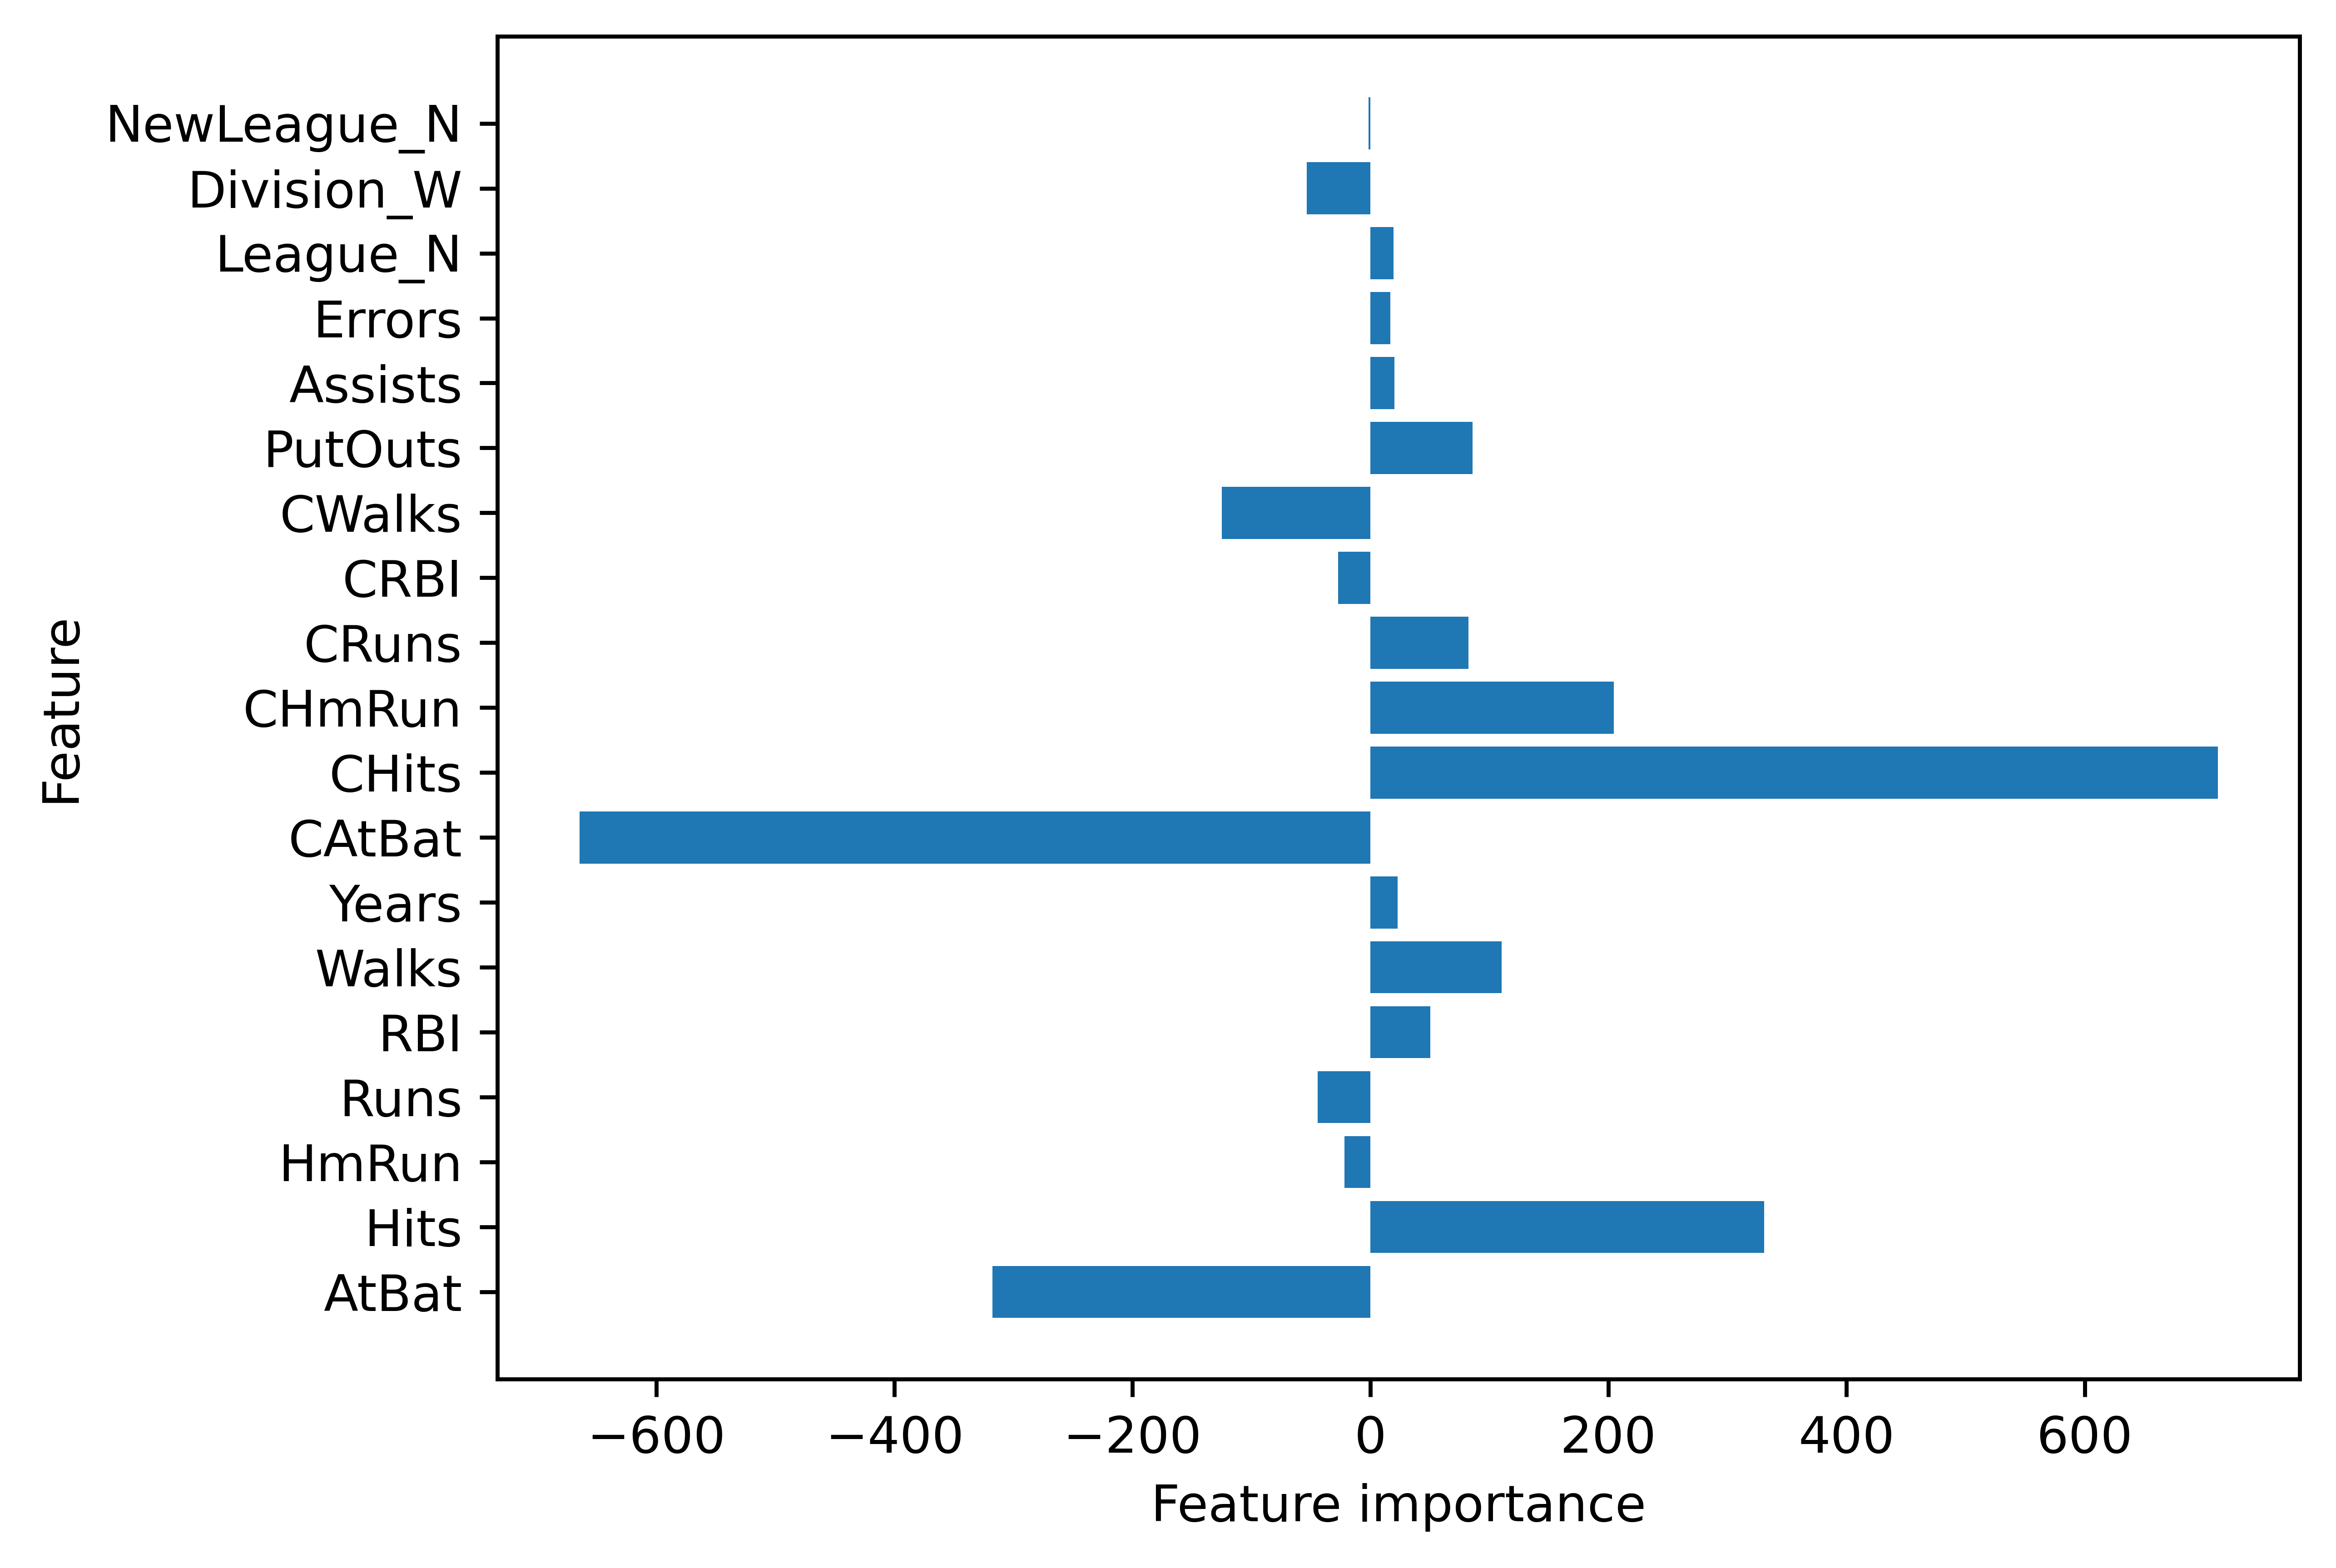

In [5]:
print("Intercept: {}".format(ols.intercept_))

n_features = len(ols.coef_)
plt.figure(dpi = 800)
plt.barh(range(n_features), ols.coef_, align='center')
plt.yticks(np.arange(n_features), X.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")

This figure allows us to extract the most important features for salary.

## Ridge regression

We try to find a good value for alpha:

In [6]:
alphas = 10**np.linspace(10,-2,100)*0.5
best_ridge, best_ridge_alpha = None, None
best_ridge_mse = float("inf")

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha, max_iter=100000)
    ridge_model.fit(X_train, y_train)  
    mse = mean_squared_error(y_test, ridge_model.predict(X_test))
    
    if mse < best_ridge_mse:
        best_ridge_mse = mse
        best_ridge = ridge_model
        best_ridge_alpha = alpha

print(best_ridge_alpha)

7.087370814634009


In [7]:
ridge = Ridge(alpha = best_ridge_alpha)
ridge.fit(X_train, y_train)
print("r^2 on train data is {}".format(ridge.score(X_train, y_train)))
print("r^2 on test data is {}".format(ridge.score(X_test, y_test)))

r^2 on train data is 0.5406631198506804
r^2 on test data is 0.4266990847733526


It's not a huge improvement, but it is indeed an improvement and there's a little less overfitting than OLS. Increasing alpha will decrease r^2 a bit, but get the two closer to each other.

Intercept: 528.8873523933225


Text(0, 0.5, 'Feature')

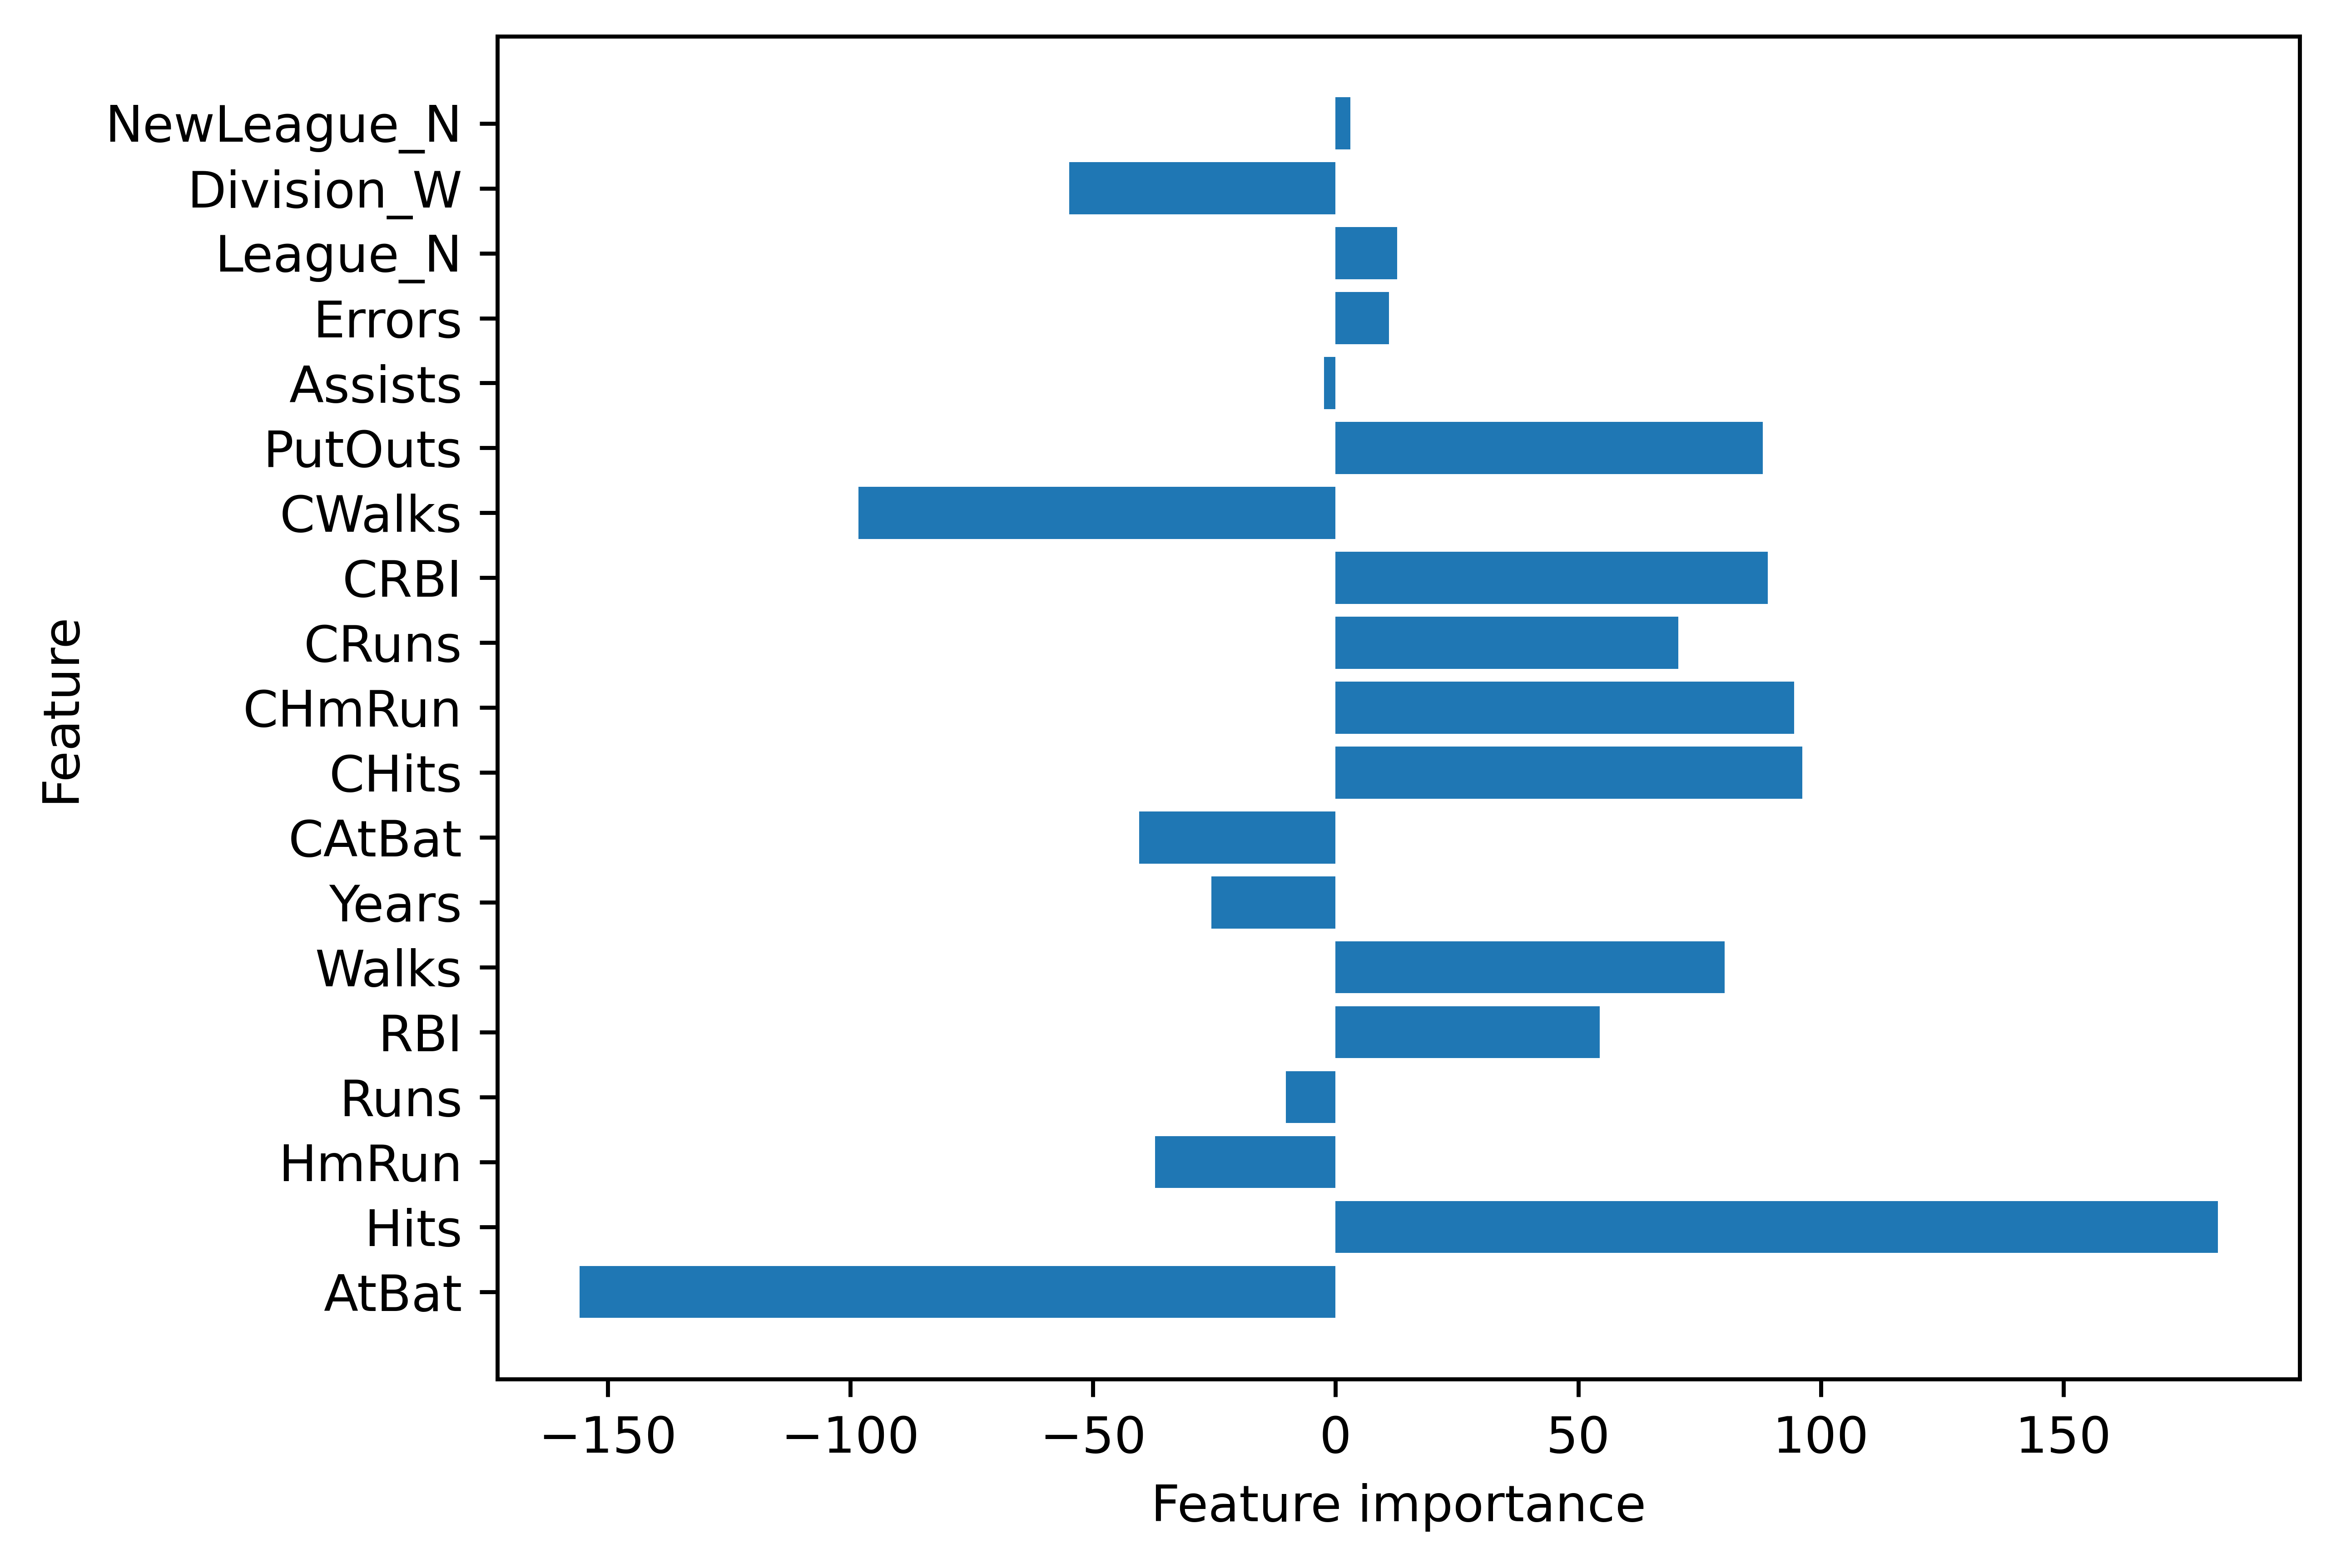

In [8]:
print("Intercept: {}".format(ridge.intercept_))

n_features = len(ridge.coef_)
plt.figure(dpi = 800)
plt.barh(range(n_features), ridge.coef_, align='center')
plt.yticks(np.arange(n_features), X.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")

Notice that the coefficients are much smaller than for OLS - that's what Ridge regression can do!

## Lasso regression

In [9]:
alphas = 10**np.linspace(10,-2,100)*0.5
best_lasso, best_lasso_alpha = None, None
best_lasso_mse = float("inf")

for alpha in alphas:
    lasso_model = Lasso(alpha=alpha, max_iter=100000)
    lasso_model.fit(X_train, y_train)  
    mse = mean_squared_error(y_test, lasso_model.predict(X_test))
    
    if mse < best_lasso_mse:
        best_lasso_mse = mse
        best_lasso = lasso_model
        best_lasso_alpha = alpha

print(best_lasso_alpha)

5.361336110051605


In [10]:
lasso = Lasso(alpha = best_lasso_alpha)
lasso.fit(X_train, y_train)
print("r^2 on train data is {}".format(lasso.score(X_train, y_train)))
print("r^2 on test data is {}".format(lasso.score(X_test, y_test)))

r^2 on train data is 0.5321720134618946
r^2 on test data is 0.4278885198538821


A similar r^2 to Ridge for the test data, but the two values are a bit closer to each other - slightly less overfitting!

Intercept: 529.8778010436948


Text(0, 0.5, 'Feature')

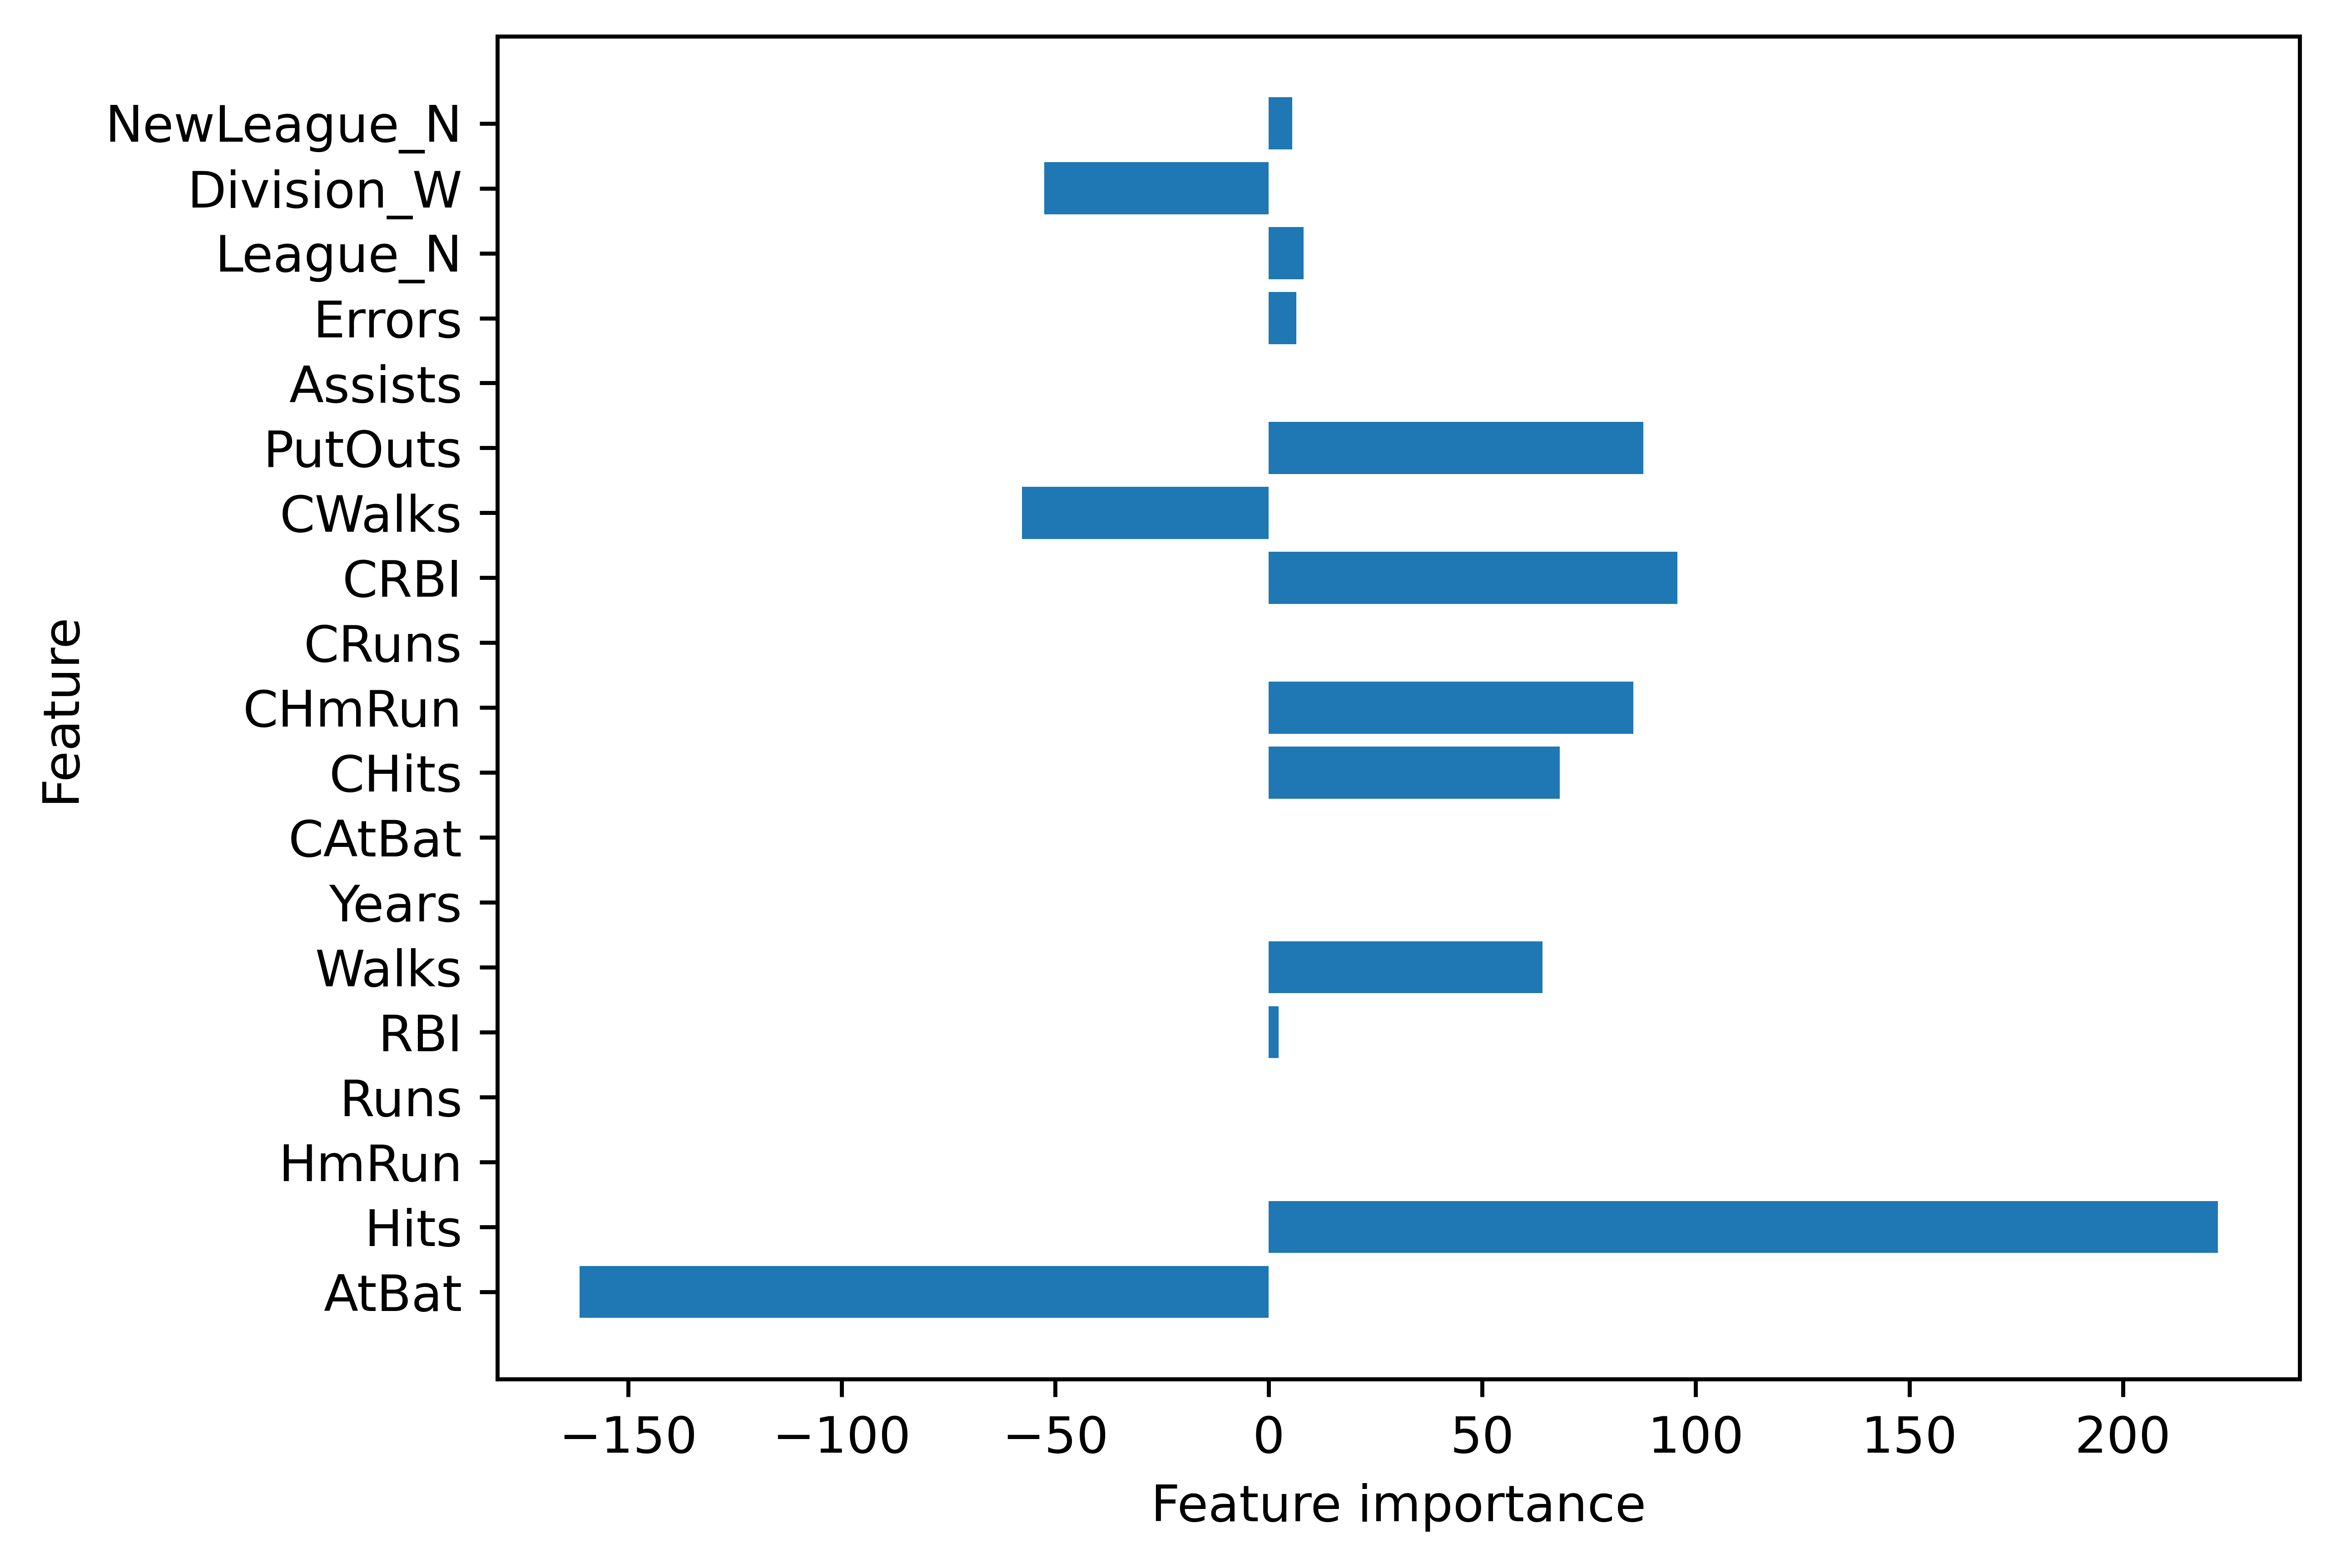

In [11]:
print("Intercept: {}".format(lasso.intercept_))

n_features = len(lasso.coef_)
plt.figure(dpi = 800)
plt.barh(range(n_features), lasso.coef_, align='center')
plt.yticks(np.arange(n_features), X.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")

Behold the power of Lasso regression: Several coefficients are exactly zero!

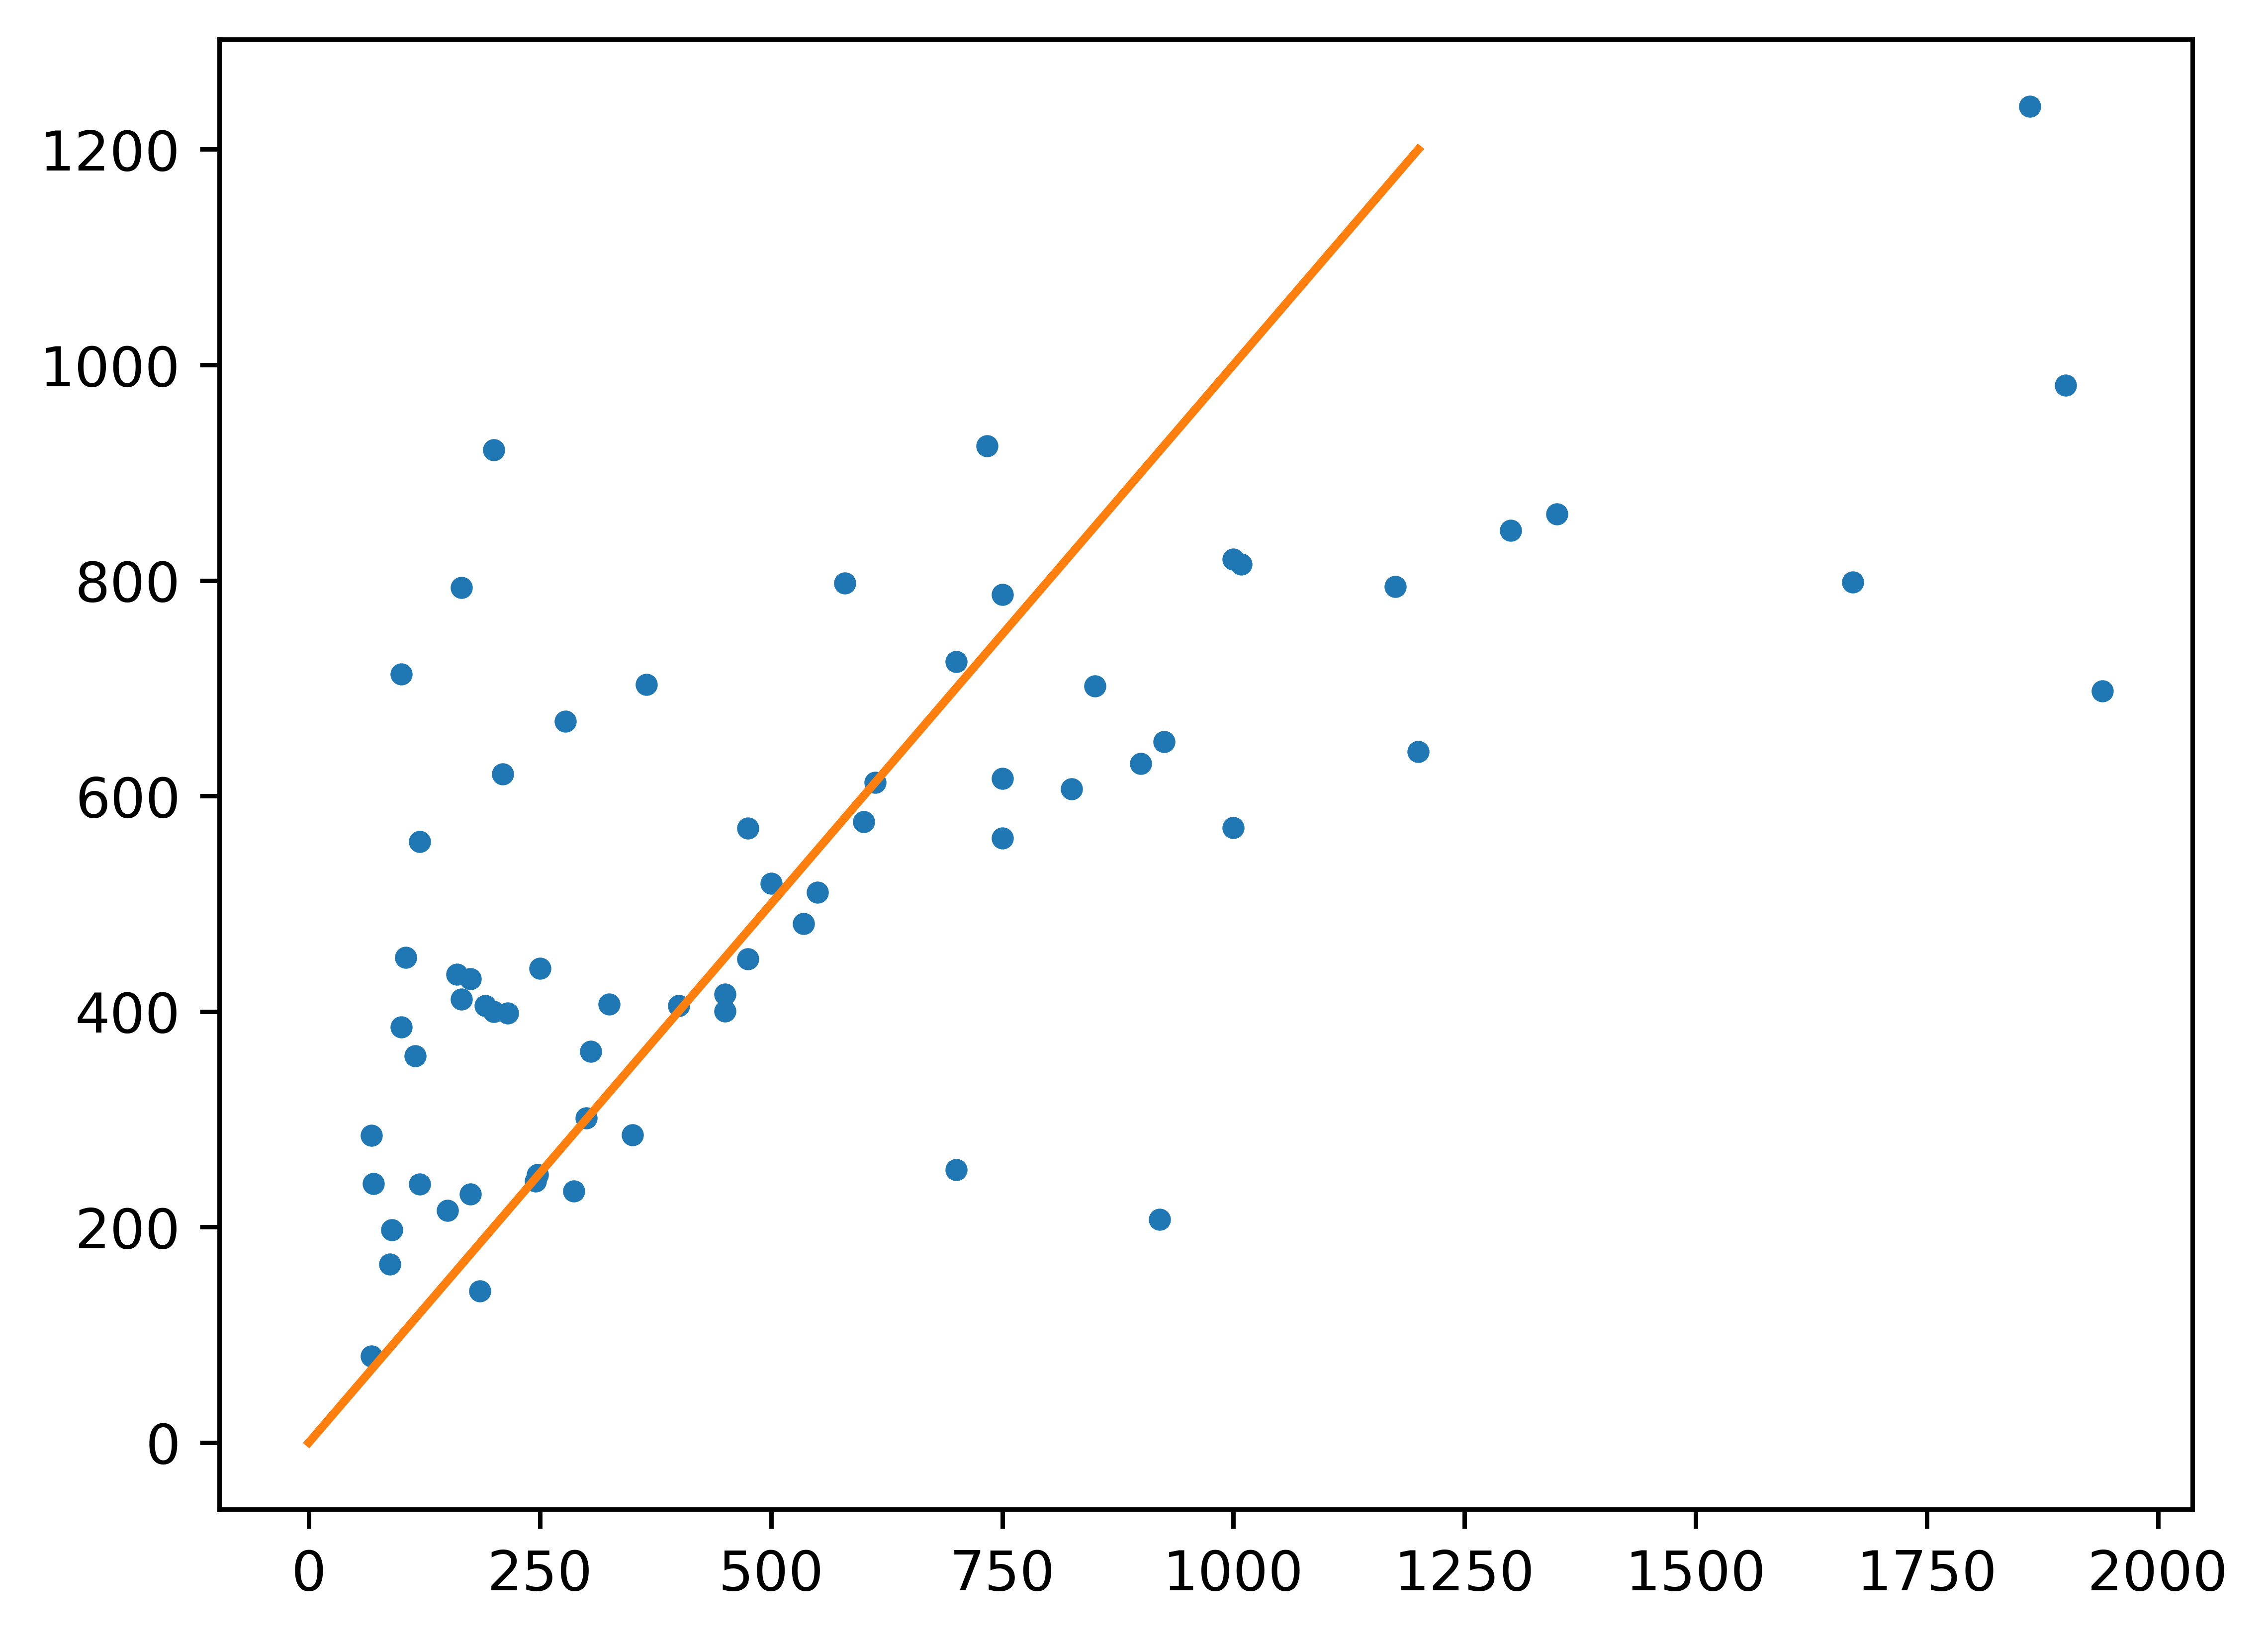

In [12]:
plt.figure(dpi=800)
plt.plot(y_test, lasso.predict(X_test),'.')
plt.plot([0,1200], [0, 1200],'-')
plt.show()